# Data Visualization
This notebook provides visualizations for the cleaned house sales data, including price trends, geospatial plots, and price distributions by zipcode.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df = pd.read_csv('data/eda_cleaned.csv')
df_centered = pd.read_csv('data/eda_central.csv')


## Price Distribution by Zipcode

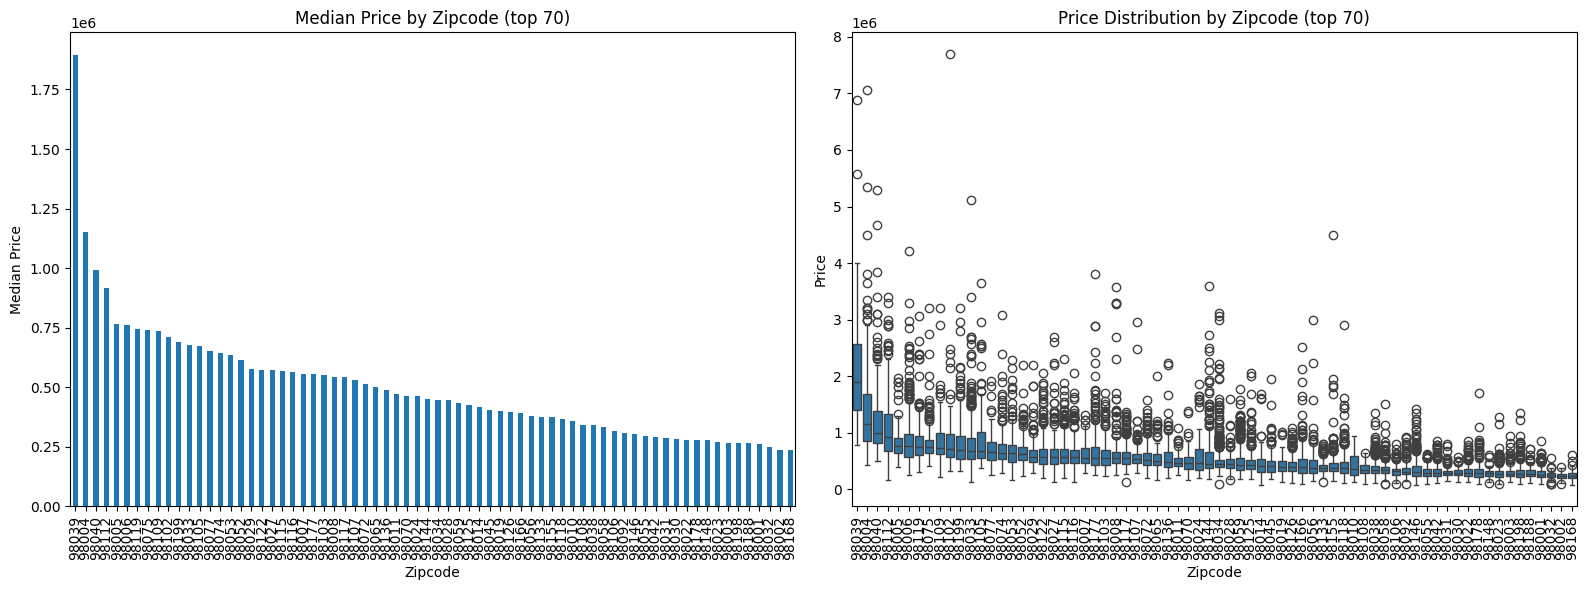

In [16]:
top_n = 70
df = df.dropna(subset=['zipcode', 'price']).copy()
top_zips = df['zipcode'].value_counts().nlargest(top_n).index.tolist()
df_top = df[df['zipcode'].isin(top_zips)].copy()
order = df_top.groupby('zipcode')['price'].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
medians = df_top.groupby('zipcode')['price'].median().reindex(order)
medians.plot.bar(ax=axes[0], color='C0')
axes[0].set_title('Median Price by Zipcode (top {})'.format(top_n))
axes[0].set_xlabel('Zipcode')
axes[0].set_ylabel('Median Price')
axes[0].tick_params(axis='x', rotation=90)
sns.boxplot(x='zipcode', y='price', data=df_top, order=order, ax=axes[1])
axes[1].set_title('Price Distribution by Zipcode (top {})'.format(top_n))
axes[1].set_xlabel('Zipcode')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## Static Map with Individual Property Data Points

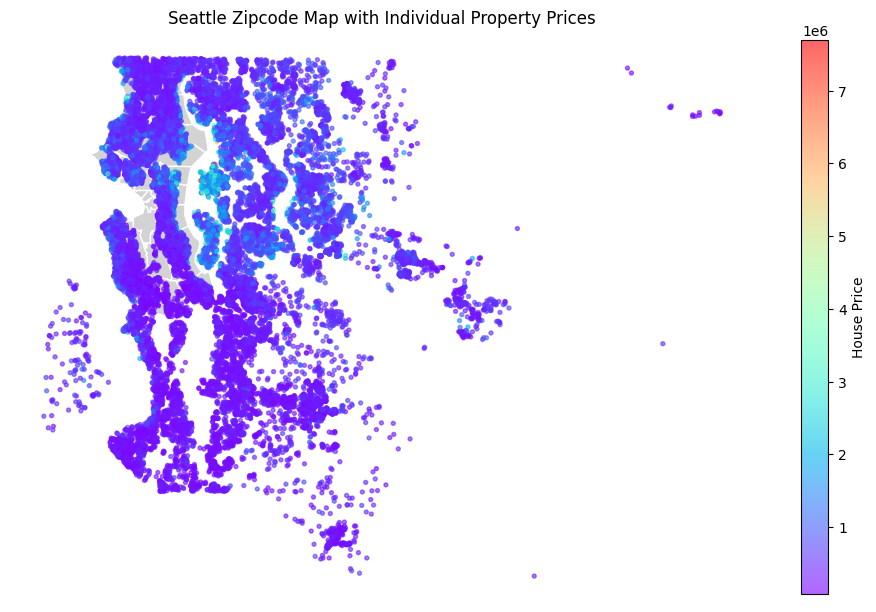

In [84]:

import matplotlib.pyplot as plt

# Create a static plot using geopandas and matplotlib
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the base map of all zip codes in light grey
merged_data.plot(ax=ax, color='lightgrey', edgecolor='white')

# Identify lat/lon columns
lat_col = 'lat' if 'lat' in df.columns else 'latitude'
lon_col = 'long' if 'long' in df.columns else 'longitude'

# Overlay the scatter plot of individual properties
if lat_col in df.columns and lon_col in df.columns:
    df_plot = df.dropna(subset=[lat_col, lon_col, 'price'])
    
    # Using 'winter' colormap which goes from blue to green
    scatter = ax.scatter(df_plot[lon_col], df_plot[lat_col], c=df_plot['price'], cmap='rainbow', s=8, alpha=0.6)
    
    # Add a colorbar for the scatter plot
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('House Price')

ax.set_title('Seattle Zipcode Map with Individual Property Prices')
ax.set_axis_off()
plt.show()


## Static Map with Price per Sqft

This map visualizes the price per square foot for each property, providing insight into housing value across Seattle.

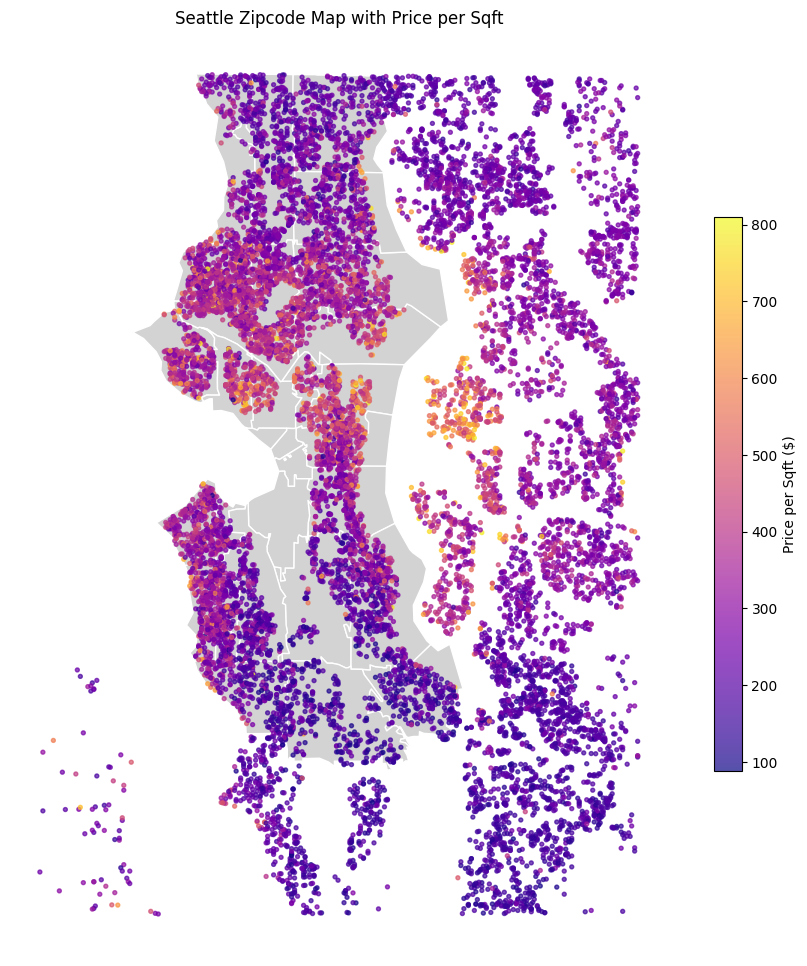

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Create a copy to avoid SettingWithCopyWarning
df_map_sqft = df.copy()

# Calculate price per sqft, handling potential zero values in sqft_living
df_map_sqft['price_per_sqft'] = df_map_sqft.apply(
    lambda row: row['price'] / row['sqft_living'] if row['sqft_living'] > 0 else np.nan, 
    axis=1
)

# Create a static plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the base map of all zip codes in light grey
merged_data.plot(ax=ax, color='lightgrey', edgecolor='white')

# Identify lat/lon columns
lat_col = 'lat' if 'lat' in df_map_sqft.columns else 'latitude'
lon_col = 'long' if 'long' in df_map_sqft.columns else 'longitude'

# Overlay the scatter plot of individual properties
if lat_col in df_map_sqft.columns and lon_col in df_map_sqft.columns:
    df_plot = df_map_sqft.dropna(subset=[lat_col, lon_col, 'price_per_sqft'])
    
    # Using 'plasma' colormap for good visual contrast
    scatter = ax.scatter(df_plot[lon_col], df_plot[lat_col], c=df_plot['price_per_sqft'], cmap='rainbow', s=8, alpha=0.7)
    
    # Add a colorbar for the scatter plot
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Price per Sqft ($)')

ax.set_title('Seattle Zipcode Map with Price per Sqft')
ax.set_axis_off()
plt.show()


## Price per Sqft: Central vs. Rest of Seattle

This box plot compares the distribution of price per square foot for properties located in central Seattle zip codes versus all other areas.

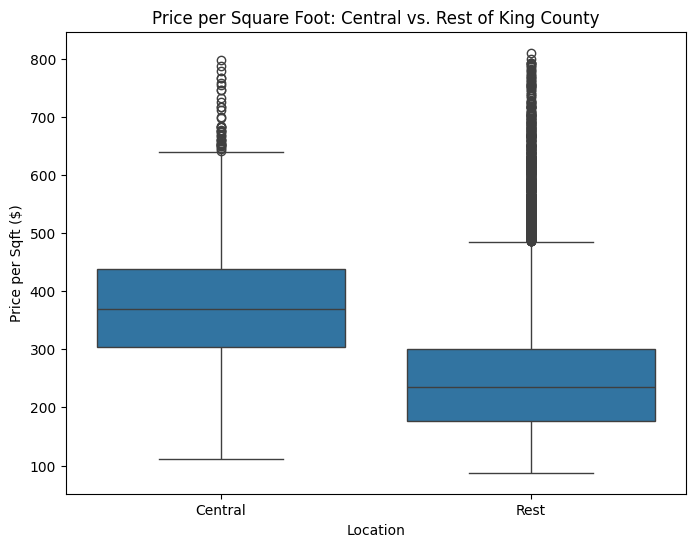

In [95]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a copy for this plot
df_box = df.copy()

# Calculate price per sqft
df_box['price_per_sqft'] = df_box.apply(
    lambda row: row['price'] / row['sqft_living'] if row['sqft_living'] > 0 else np.nan, 
    axis=1
)

# Define central zip codes
central_zips = ["98101", "98102", "98103", "98104", "98105", "98109", "98112", "98121", "98122", "98144"]

# Categorize properties into 'Central' and 'Rest'
df_box['location_type'] = df_box['zipcode'].astype(str).apply(
    lambda z: 'Central' if z in central_zips else 'Rest'
)

# Drop rows with no price_per_sqft to ensure clean plot
df_box.dropna(subset=['price_per_sqft'], inplace=True)

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='location_type', y='price_per_sqft', data=df_box, order=['Central', 'Rest'])
plt.title('Price per Square Foot: Central vs. Rest of King County')
plt.xlabel('Location')
plt.ylabel('Price per Sqft ($)')
plt.show()


## Median Price per Square Foot Over Time

This plot shows the trend of the median price per square foot on a monthly basis.

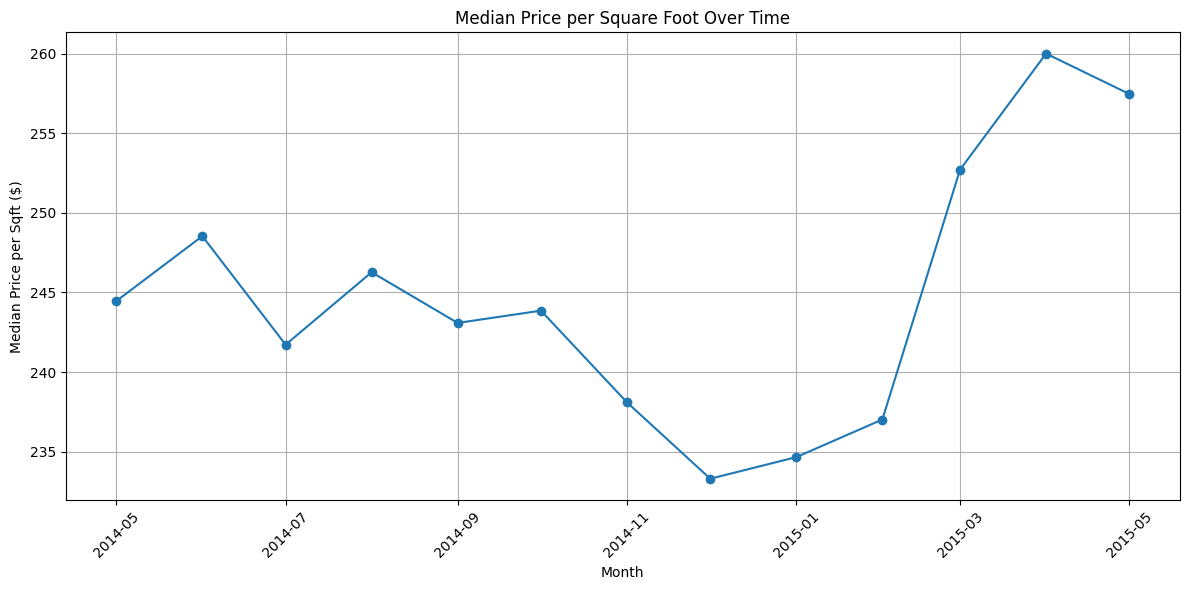

In [122]:

import matplotlib.pyplot as plt
import numpy as np

# Create a copy for this plot
df_time = df.copy()

# Ensure 'date' is in datetime format
df_time['date'] = pd.to_datetime(df_time['date'], errors='coerce')

# Calculate price per sqft
df_time['price_per_sqft'] = df_time.apply(
    lambda row: row['price'] / row['sqft_living'] if row['sqft_living'] > 0 else np.nan, 
    axis=1
)

# Drop rows where date or price_per_sqft is missing
df_time.dropna(subset=['date', 'price_per_sqft'], inplace=True)

# Create a 'month' column for grouping
df_time['month'] = df_time['date'].dt.to_period('M')

# Calculate the median price per sqft per month
median_price_per_month = df_time.groupby('month')['price_per_sqft'].median()

# Convert PeriodIndex to a format that can be plotted easily
plot_data = median_price_per_month.to_timestamp()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(plot_data.index, plot_data.values, marker='o', linestyle='-')
plt.title('Median Price per Square Foot Over Time')
plt.xlabel('Month')
plt.ylabel('Median Price per Sqft ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Number of Sales per Month

This bar chart shows the total number of property sales for each month in the dataset.

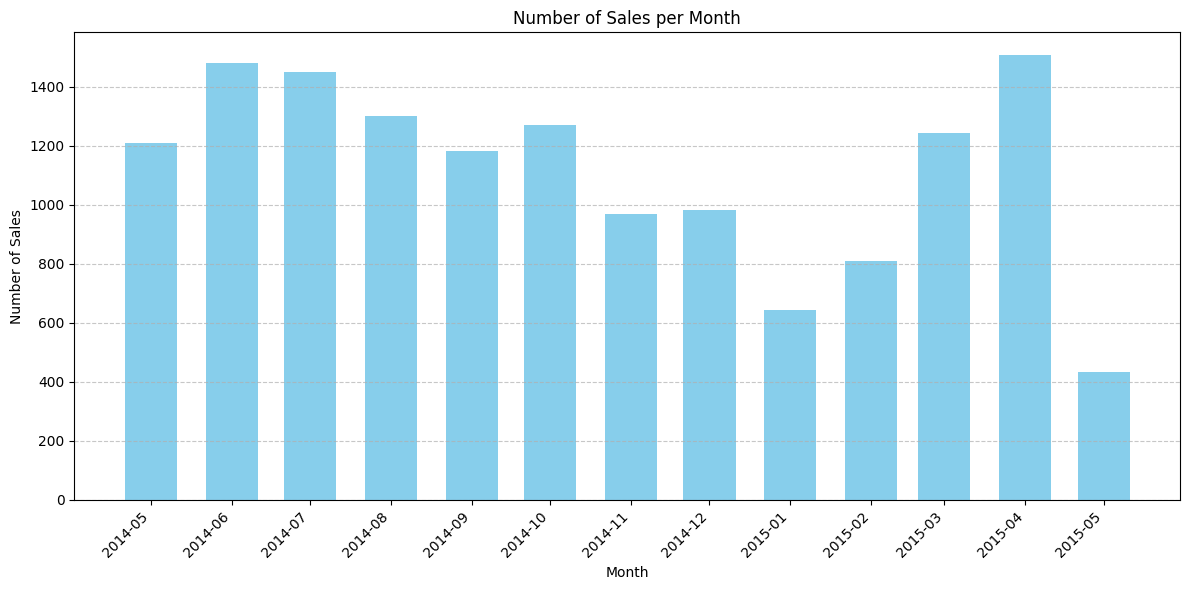

In [53]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create a copy for this plot
df_sales = df.copy()

# Ensure 'date' is in datetime format
df_sales['date'] = pd.to_datetime(df_sales['date'], errors='coerce')

# Drop rows where date is missing
df_sales.dropna(subset=['date'], inplace=True)

# Create a 'month' column for grouping
df_sales['month'] = df_sales['date'].dt.to_period('M')

# Count the number of sales per month
sales_per_month = df_sales['month'].value_counts().sort_index()

# Convert PeriodIndex to a format that can be plotted easily
plot_data = sales_per_month.to_timestamp()

# Create the bar plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_data.index, plot_data.values, width=20, color='skyblue')

# Format the x-axis to show only month and year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# --- Formatting ---
ax.set_title('Number of Sales per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Sales')
fig.autofmt_xdate(rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Median Price per Square Foot by Zipcode Map

This map shows the median price per square foot for each zipcode area, providing a normalized view of property value across the city.

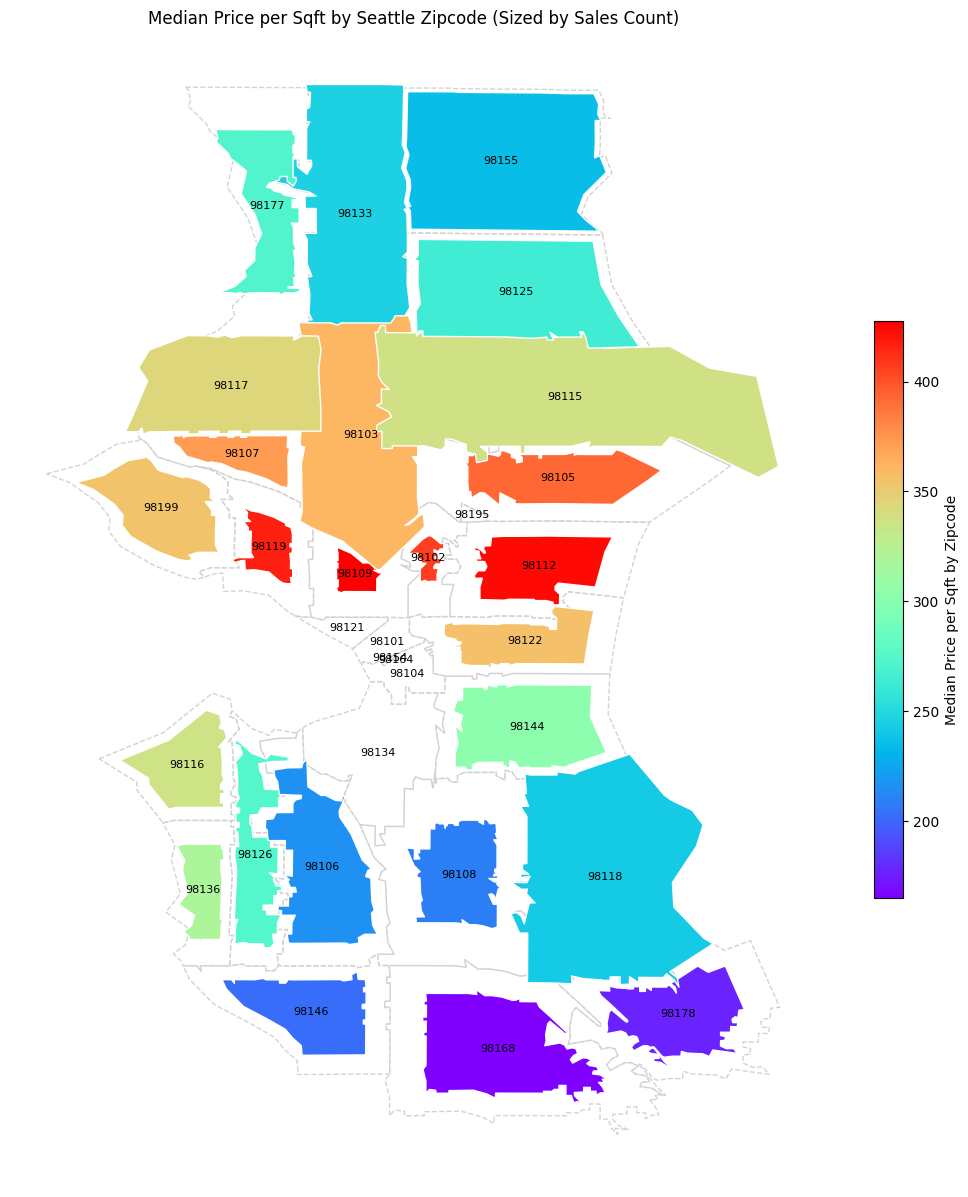

In [107]:

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.affinity import scale

# --- Data Preparation ---
# Create a copy to be safe
df_zip_sqft = df.copy()

# Calculate price per sqft, handling potential zero values
df_zip_sqft['price_per_sqft'] = df_zip_sqft.apply(
    lambda row: row['price'] / row['sqft_living'] if row['sqft_living'] > 0 else np.nan, 
    axis=1
)

# Ensure zipcode is a string for grouping and merging
df_zip_sqft['zipcode'] = df_zip_sqft['zipcode'].astype(str)

# 1. Calculate the median price per sqft for each zipcode
median_sqft_by_zip = df_zip_sqft.groupby('zipcode')['price_per_sqft'].median().reset_index()

# 2. Calculate the number of sales (value count) for each zipcode
sales_by_zip = df_zip_sqft['zipcode'].value_counts().reset_index()
sales_by_zip.columns = ['zipcode', 'sales_count']

# --- Merging with GeoData ---
# Load the GeoJSON file
seattle_zip_geo = gpd.read_file('data/seattle_zipcodes.geojson')
zip_col_name = 'ZCTA5CE10'
seattle_zip_geo[zip_col_name] = seattle_zip_geo[zip_col_name].astype(str)

# Merge both median price and sales count data with the geo data
merged_sqft_data = seattle_zip_geo.merge(median_sqft_by_zip, left_on=zip_col_name, right_on='zipcode', how='left')
merged_sqft_data = merged_sqft_data.merge(sales_by_zip, left_on=zip_col_name, right_on='zipcode', how='left')

# --- Geometry Scaling ---
# Normalize sales count to a scaling factor (e.g., from 0.4 to 1.2)
min_scale = 0.4
max_scale = 1.2
min_count = merged_sqft_data['sales_count'].min()
max_count = merged_sqft_data['sales_count'].max()

merged_sqft_data['scale_factor'] = merged_sqft_data['sales_count'].apply(
    lambda count: min_scale + (max_scale - min_scale) * (count - min_count) / (max_count - min_count) if pd.notna(count) else min_scale
)

# Create a new geometry column with scaled polygons
# The origin for scaling is the polygon's own centroid
merged_sqft_data['scaled_geometry'] = merged_sqft_data.apply(
    lambda row: scale(row['geometry'], xfact=row['scale_factor'], yfact=row['scale_factor'], origin=row['geometry'].centroid),
    axis=1
)
# Set the active geometry to the new scaled polygons
merged_sqft_data = merged_sqft_data.set_geometry('scaled_geometry')


# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the base map of original zip code boundaries in light grey for context
seattle_zip_geo.plot(ax=ax, color='none', edgecolor='lightgrey', linestyle='--')

# Plot the scaled choropleth for zip codes with price data on top
merged_sqft_data.dropna(subset=['price_per_sqft']).plot(column='price_per_sqft', ax=ax, legend=True,
                 cmap='rainbow', edgecolor='white',
                 legend_kwds={'label': "Median Price per Sqft by Zipcode",
                              'orientation': "vertical", 'shrink': 0.5})

# Add zipcode labels to the plot
for idx, row in merged_sqft_data.iterrows():
    # Use the centroid of the original geometry for label placement
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row[zip_col_name], fontsize=8, ha='center', va='center', color='black')

ax.set_title('Median Price per Sqft by Seattle Zipcode (Sized by Sales Count)')
ax.set_axis_off()
plt.show()



## Median Price by Zipcode Map (Sized by Sales Count)

This map is similar to the one above, but it uses the absolute median house price for the color scale, while still using the sales count to determine the size of each zipcode area.


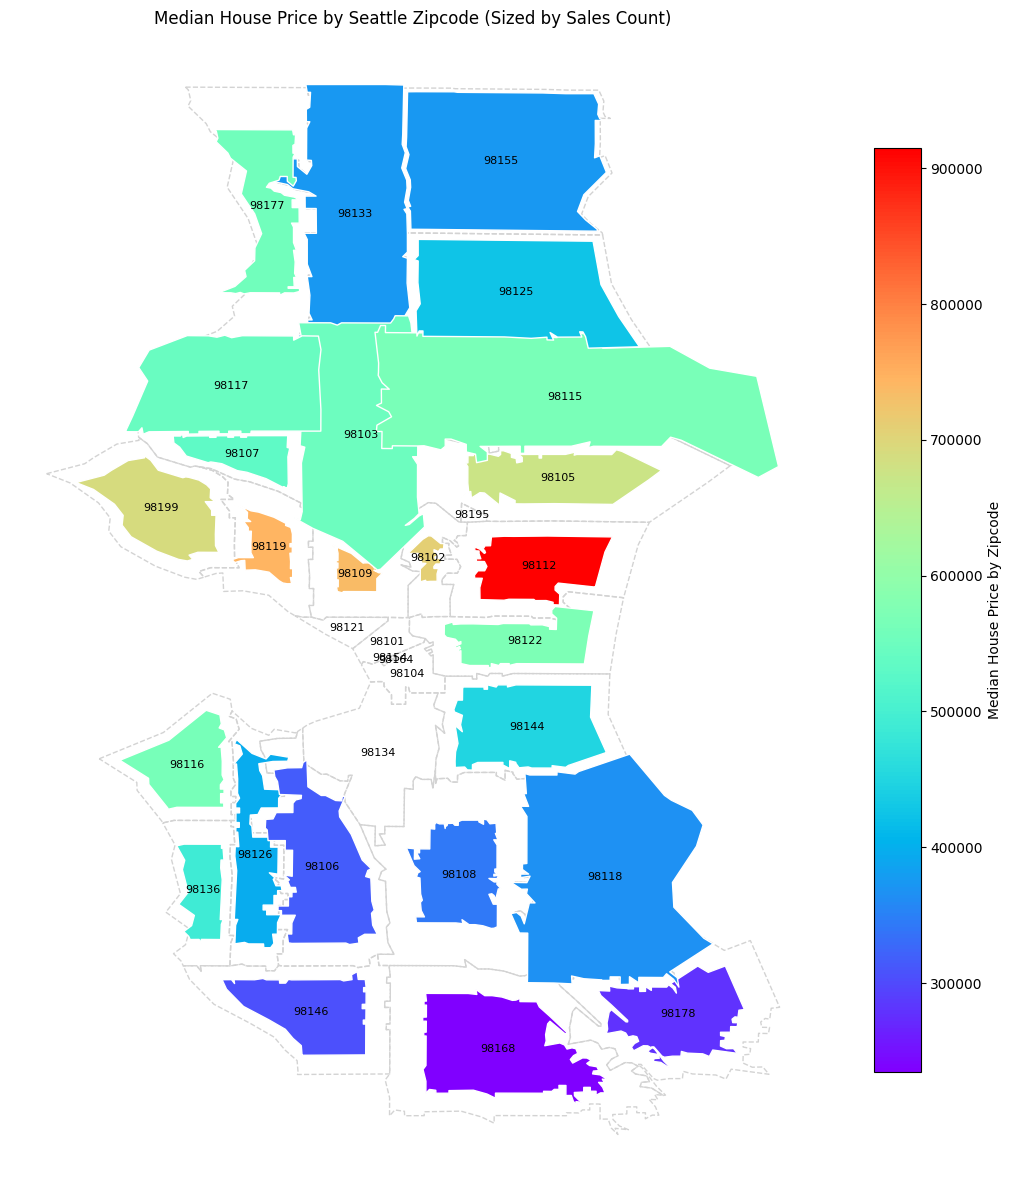

In [106]:

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.affinity import scale

# --- Data Preparation ---
# Create a copy to be safe
df_zip_price = df.copy()

# Ensure zipcode is a string for grouping and merging
df_zip_price['zipcode'] = df_zip_price['zipcode'].astype(str)

# 1. Calculate the median price for each zipcode
median_price_by_zip = df_zip_price.groupby('zipcode')['price'].median().reset_index()

# 2. Calculate the number of sales (value count) for each zipcode
sales_by_zip = df_zip_price['zipcode'].value_counts().reset_index()
sales_by_zip.columns = ['zipcode', 'sales_count']

# --- Merging with GeoData ---
# Load the GeoJSON file
seattle_zip_geo = gpd.read_file('data/seattle_zipcodes.geojson')
zip_col_name = 'ZCTA5CE10'
seattle_zip_geo[zip_col_name] = seattle_zip_geo[zip_col_name].astype(str)

# Merge both median price and sales count data with the geo data
merged_price_data = seattle_zip_geo.merge(median_price_by_zip, left_on=zip_col_name, right_on='zipcode', how='left')
merged_price_data = merged_price_data.merge(sales_by_zip, left_on=zip_col_name, right_on='zipcode', how='left')

# --- Geometry Scaling ---
# Normalize sales count to a scaling factor (e.g., from 0.4 to 1.2)
min_scale = 0.4
max_scale = 1.2
min_count = merged_price_data['sales_count'].min()
max_count = merged_price_data['sales_count'].max()

merged_price_data['scale_factor'] = merged_price_data['sales_count'].apply(
    lambda count: min_scale + (max_scale - min_scale) * (count - min_count) / (max_count - min_count) if pd.notna(count) else min_scale
)

# Create a new geometry column with scaled polygons
merged_price_data['scaled_geometry'] = merged_price_data.apply(
    lambda row: scale(row['geometry'], xfact=row['scale_factor'], yfact=row['scale_factor'], origin=row['geometry'].centroid),
    axis=1
)
# Set the active geometry to the new scaled polygons
merged_price_data = merged_price_data.set_geometry('scaled_geometry')


# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the base map of original zip code boundaries in light grey for context
seattle_zip_geo.plot(ax=ax, color='none', edgecolor='lightgrey', linestyle='--')

# Plot the scaled choropleth for zip codes with price data on top
merged_price_data.dropna(subset=['price']).plot(column='price', ax=ax, legend=True,
                 cmap='rainbow', edgecolor='white',
                 legend_kwds={'label': "Median House Price by Zipcode",
                              'orientation': "vertical", 'shrink': 0.8})

# Add zipcode labels to the plot
for idx, row in merged_price_data.iterrows():
    # Use the centroid of the original geometry for label placement
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row[zip_col_name], fontsize=8, ha='center', va='center', color='black')

ax.set_title('Median House Price by Seattle Zipcode (Sized by Sales Count)')
ax.set_axis_off()
plt.show()



## Median Price by Neighborhood Map
This map visualizes the median house price for the defined Seattle neighborhoods. Each neighborhood is a distinct colored area, formed by merging the corresponding zip code shapes.


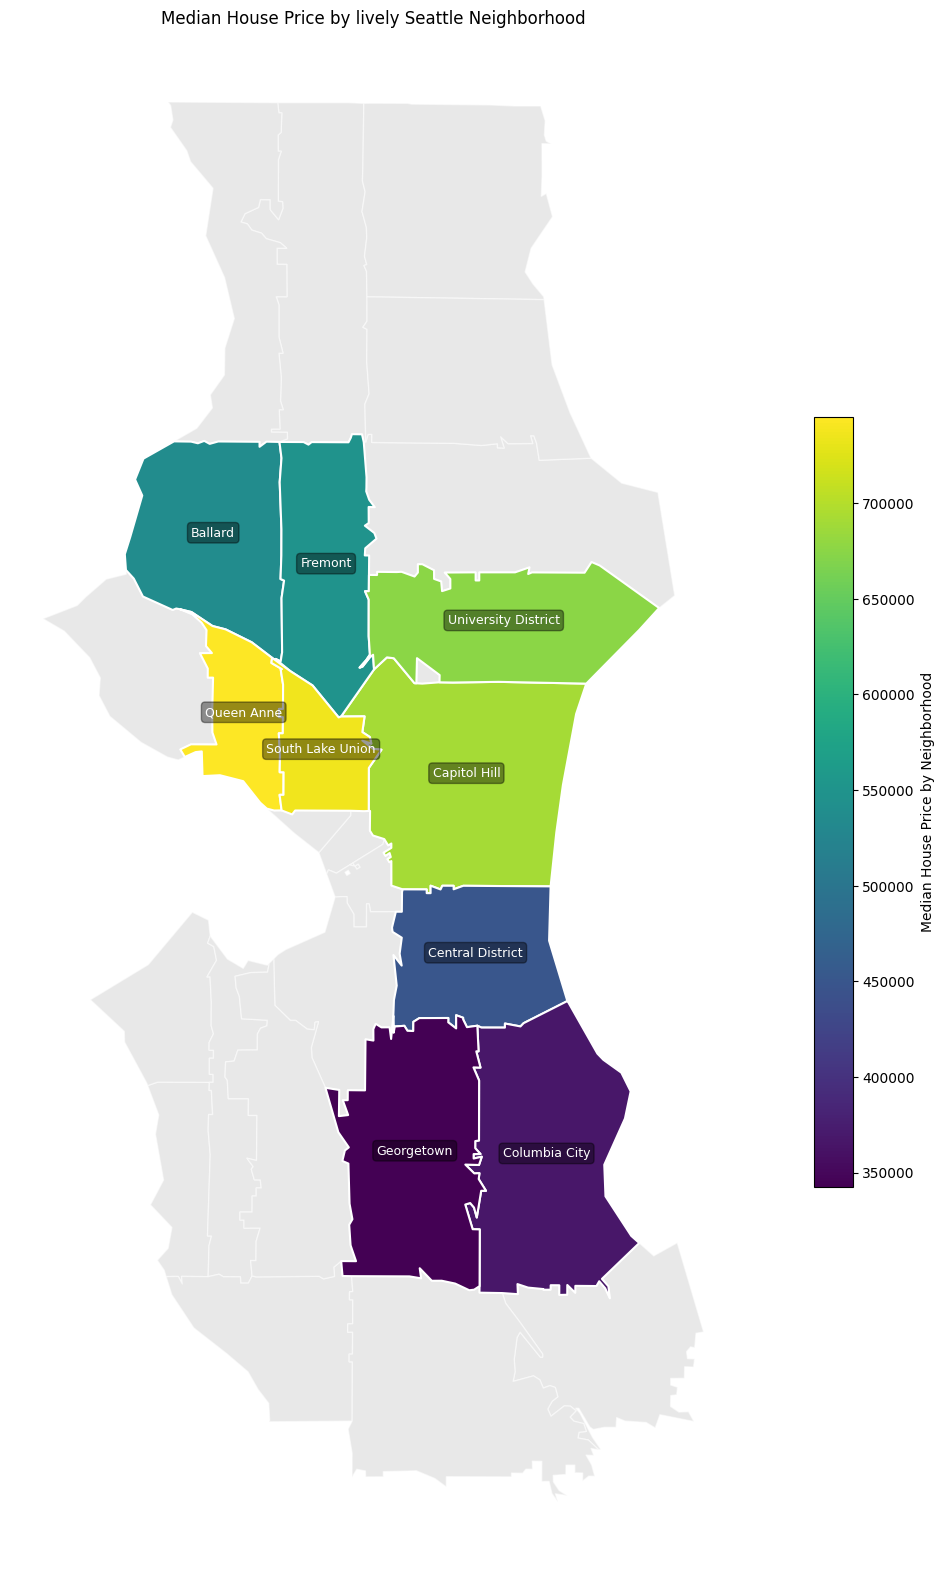

In [113]:

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# --- Data Preparation ---
# Define the neighborhood to zip code mapping (re-using from the previous cell)
neighborhood_zips = {
    'Capitol Hill': [98102, 98112, 98122],
    'Ballard': [98107, 98117],
    'Fremont': [98103, 98107],
    'University District': [98105],
    'South Lake Union': [98109],
    'Queen Anne': [98109, 98119],
    'Georgetown': [98108],
    'Columbia City': [98118],
    'Central District': [98122, 98144]
}

# Create a reverse mapping from zip code to the first neighborhood it appears in
zip_to_neighborhood = {}
for neighborhood, zips in neighborhood_zips.items():
    for zip_code in zips:
        if zip_code not in zip_to_neighborhood: # Assign to first encountered neighborhood
            zip_to_neighborhood[zip_code] = neighborhood

# --- Geospatial Operations ---
# Load the zip code geometries
seattle_zip_geo = gpd.read_file('data/seattle_zipcodes.geojson')
zip_col_name = 'ZCTA5CE10'
seattle_zip_geo['zipcode'] = seattle_zip_geo[zip_col_name].astype(int)

# Map the geometries to neighborhood names
seattle_zip_geo['neighborhood'] = seattle_zip_geo['zipcode'].map(zip_to_neighborhood)

# Filter out any zip codes that are not part of our defined neighborhoods
mapped_geos = seattle_zip_geo.dropna(subset=['neighborhood'])

# Dissolve the zip code polygons into a single polygon for each neighborhood
# This creates the neighborhood outlines
neighborhood_boundaries = mapped_geos.dissolve(by='neighborhood')

# --- Price Calculation ---
# Map the original dataframe to neighborhoods and calculate median price
df_neighborhood_prices = df.copy()
df_neighborhood_prices['neighborhood'] = df_neighborhood_prices['zipcode'].map(zip_to_neighborhood)
median_price_by_neighborhood = df_neighborhood_prices.dropna(subset=['neighborhood']).groupby('neighborhood')['price'].median().reset_index()

# --- Merging for Plot ---
# Merge the median price data with the dissolved neighborhood geometries
# The neighborhood name is in the index of the 'neighborhood_boundaries' GeoDataFrame
merged_neighborhood_data = neighborhood_boundaries.merge(median_price_by_neighborhood, left_index=True, right_on='neighborhood', how='left')


# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

# Plot the base map of all Seattle zip codes in light grey for context
seattle_zip_geo.plot(ax=ax, color='lightgrey', edgecolor='white', alpha=0.5)

# Plot the neighborhood choropleth on top
merged_neighborhood_data.plot(column='price', ax=ax, legend=True,
                              cmap='viridis', edgecolor='white', linewidth=1.5,
                              legend_kwds={'label': "Median House Price by Neighborhood",
                                           'orientation': "vertical", 'shrink': 0.5})

# Add neighborhood labels
for idx, row in merged_neighborhood_data.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['neighborhood'], fontsize=9, ha='center', color='white',
            bbox=dict(facecolor='black', alpha=0.4, boxstyle='round,pad=0.3'))

# --- Formatting ---
ax.set_title('Median House Price by lively Seattle Neighborhood')
ax.set_axis_off()
plt.show()
